In [1]:
# ============================================================
# CELL 1: Install & Import All Required Libraries
# ============================================================
# In Google Colab, most libraries are pre-installed.
# We upgrade scikit-learn just to be safe.

!pip install scikit-learn --upgrade -q

# --- Data manipulation ---
import numpy as np              # Numerical computing (arrays, math)
import pandas as pd             # Data loading and manipulation

# --- Visualization ---
import matplotlib.pyplot as plt  # Plotting library
import seaborn as sns            # Statistical data visualization

# --- Machine Learning (Scikit-learn) ---
from sklearn.datasets import load_iris, load_wine, load_diabetes
# load_iris     -> classic flower classification dataset (3 classes)
# load_wine     -> wine quality classification dataset
# load_diabetes -> regression dataset (for later cells)

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
# train_test_split  -> splits data into training and testing sets
# cross_val_score   -> k-fold cross validation
# GridSearchCV      -> hyperparameter tuning

from sklearn.preprocessing import StandardScaler, LabelEncoder
# StandardScaler -> normalizes features (VERY important for KNN!)
# LabelEncoder   -> encodes text labels to numbers

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
# KNeighborsClassifier -> KNN for classification tasks
# KNeighborsRegressor  -> KNN for regression tasks

from sklearn.metrics import (
    accuracy_score,        # % of correct predictions
    classification_report, # precision, recall, F1 per class
    confusion_matrix,      # matrix of true vs predicted labels
    ConfusionMatrixDisplay,# visual confusion matrix
    mean_squared_error,    # for regression evaluation
    r2_score               # R² score for regression
)

from matplotlib.colors import ListedColormap  # For decision boundary colors

# --- Settings ---
plt.rcParams['figure.figsize'] = (10, 6)  # Default plot size
sns.set_style('whitegrid')               # Clean plot background
np.random.seed(42)                        # Reproducible results

print("✅ All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 60.2 MB/s eta 0:00:00
✅ All libraries imported successfully!


In [2]:
# ============================================================
# CELL 2: Load & Explore the Iris Dataset
# ============================================================
# The Iris dataset has 150 samples of flowers.
# 4 features: sepal length, sepal width, petal length, petal width
# 3 target classes: Setosa, Versicolor, Virginica

# --- Load dataset ---
iris = load_iris()

# Convert to a Pandas DataFrame for easy exploration
df = pd.DataFrame(
    data=iris.data,             # Feature values (the X)
    columns=iris.feature_names  # Column names from dataset
)
df['species'] = iris.target         # Add target column (0, 1, 2)
df['species_name'] = df['species'].map(
    {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
)  # Human-readable labels

# --- Basic Info ---
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("=== First 5 Rows ===")
print(df.head())

print("\n=== Class Distribution ===")
print(df['species_name'].value_counts())
# Good to check: is the data balanced? (equal samples per class?)

print("\n=== Statistical Summary ===")
print(df.describe().round(2))
# Shows min, max, mean, std for each feature
# KNN is distance-based, so large differences in scale matter!

print("\n=== Missing Values ===")
print(df.isnull().sum())
# Always check for nulls before training any model

=== Dataset Shape ===
Rows: 150, Columns: 6

=== First 5 Rows ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

=== Class Distribution ===
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

=== Statistical Summary ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84  

/tmp/ipykernel_7758/1377127597.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=15)


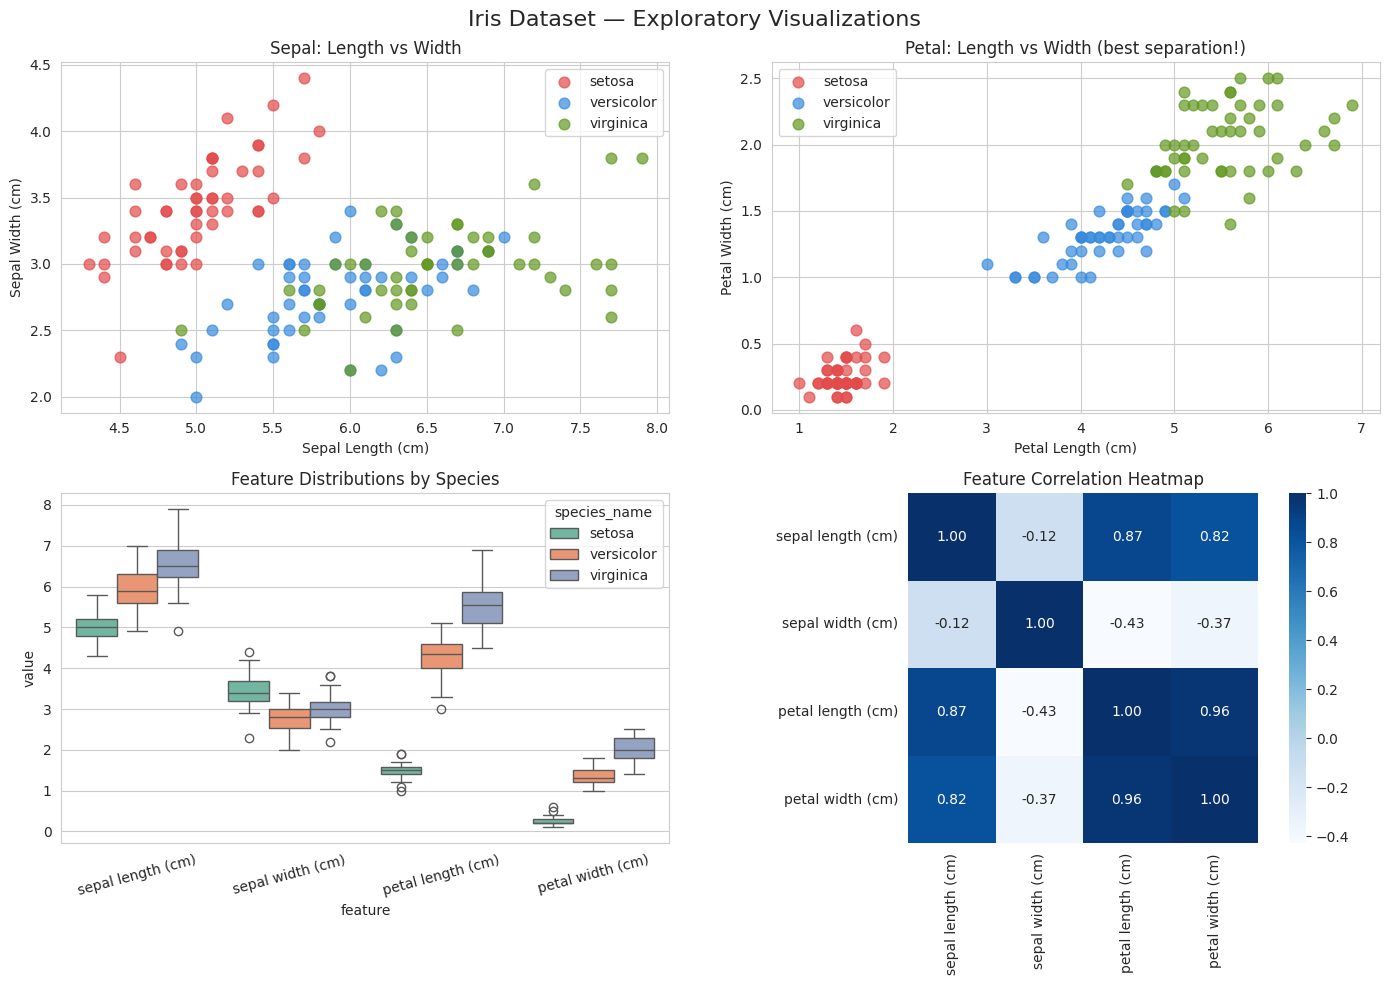

💡 Notice: Petal features separate classes much better than sepal features!


In [3]:
# ============================================================
# CELL 3: Visualize the Data
# ============================================================
# Always visualize before modeling — it helps you understand
# class separability and feature distributions.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Iris Dataset — Exploratory Visualizations', fontsize=16)

colors = ['#E24B4A', '#378ADD', '#639922']  # One color per class
species = ['setosa', 'versicolor', 'virginica']

# --- Plot 1: Sepal Length vs Sepal Width (scatter) ---
for i, sp in enumerate(species):
    subset = df[df['species_name'] == sp]
    axes[0, 0].scatter(
        subset['sepal length (cm)'],
        subset['sepal width (cm)'],
        label=sp, color=colors[i], alpha=0.7, s=60
    )
axes[0, 0].set_title('Sepal: Length vs Width')
axes[0, 0].set_xlabel('Sepal Length (cm)')
axes[0, 0].set_ylabel('Sepal Width (cm)')
axes[0, 0].legend()

# --- Plot 2: Petal Length vs Petal Width (scatter) ---
for i, sp in enumerate(species):
    subset = df[df['species_name'] == sp]
    axes[0, 1].scatter(
        subset['petal length (cm)'],
        subset['petal width (cm)'],
        label=sp, color=colors[i], alpha=0.7, s=60
    )
axes[0, 1].set_title('Petal: Length vs Width (best separation!)')
axes[0, 1].set_xlabel('Petal Length (cm)')
axes[0, 1].set_ylabel('Petal Width (cm)')
axes[0, 1].legend()

# --- Plot 3: Feature distributions (box plot) ---
df_melt = df.melt(
    id_vars=['species_name'],
    value_vars=iris.feature_names,
    var_name='feature', value_name='value'
)
sns.boxplot(
    data=df_melt, x='feature', y='value',
    hue='species_name', ax=axes[1, 0], palette='Set2'
)
axes[1, 0].set_title('Feature Distributions by Species')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=15)

# --- Plot 4: Correlation heatmap ---
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            ax=axes[1, 1], square=True)
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()
print("💡 Notice: Petal features separate classes much better than sepal features!")

In [4]:
# ============================================================
# CELL 4: Preprocessing & Train/Test Split
# ============================================================
# We separate the data into:
#   X -> features (inputs the model learns from)
#   y -> target  (labels the model tries to predict)

# --- Separate features and target ---
X = iris.data    # Shape: (150, 4) — 150 samples, 4 features
y = iris.target  # Shape: (150,)  — 150 labels (0, 1, or 2)

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"Unique classes: {np.unique(y)}")

# --- Train/Test Split ---
# test_size=0.2  -> 20% data goes to testing,  80% for training
# random_state=42-> seed for reproducibility (same split every run)
# stratify=y     -> ensures each class is equally represented
#                   in both train and test sets (very important!)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # Preserves class proportions
)

print(f"\n--- After Split ---")
print(f"Training samples: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing  samples: {X_test.shape[0]}  ({X_test.shape[0]/len(X)*100:.0f}%)")

# Verify stratification worked
print(f"\nTrain class distribution: {np.bincount(y_train)}")
print(f"Test  class distribution: {np.bincount(y_test)}")
# Both should show roughly equal counts per class

Features shape: (150, 4)
Target shape:   (150,)
Unique classes: [0 1 2]

--- After Split ---
Training samples: 120 (80%)
Testing  samples: 30  (20%)

Train class distribution: [40 40 40]
Test  class distribution: [10 10 10]


=== Before Scaling (X_train) ===
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
mean               5.84              3.05               3.77              1.20
std                0.84              0.45               1.77              0.76
min                4.30              2.00               1.10              0.10
max                7.90              4.40               6.90              2.50

=== After Scaling (X_train_scaled) ===
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
mean              -0.00             -0.00               0.00              0.00
std                1.00              1.00               1.00              1.00
min               -1.84             -2.35              -1.52             -1.45
max                2.46              3.03               1.78              1.71


/tmp/ipykernel_7758/71682037.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


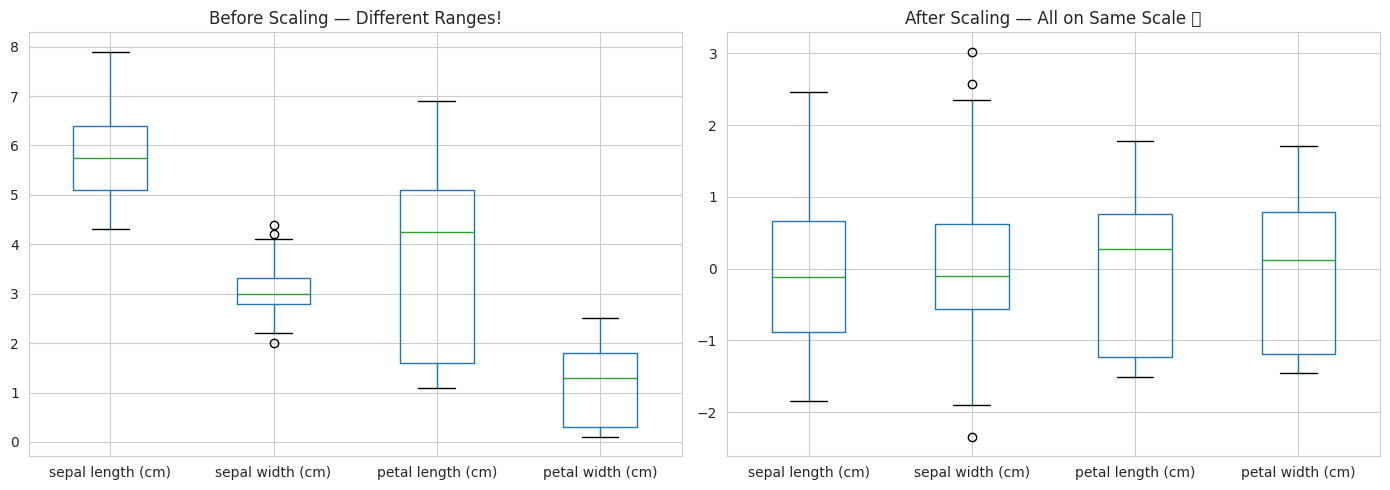

In [5]:
# ============================================================
# CELL 5: Feature Scaling (StandardScaler)
# ============================================================
# WHY IS SCALING CRITICAL FOR KNN?
# KNN calculates the DISTANCE between data points.
# If Feature A ranges from 0-1 and Feature B ranges from 0-1000,
# Feature B will dominate the distance calculation — UNFAIRLY!
#
# StandardScaler transforms each feature to:
#   mean = 0, standard deviation = 1
# Formula: z = (x - mean) / std

scaler = StandardScaler()

# IMPORTANT RULE:
# Fit ONLY on training data — NEVER on test data!
# Reason: In real life, you won't have test data when building
# the model. Fitting on test data would cause "data leakage".

X_train_scaled = scaler.fit_transform(X_train)  # Fit + Transform
X_test_scaled  = scaler.transform(X_test)        # Transform ONLY (no fit!)

# --- Verify scaling worked ---
print("=== Before Scaling (X_train) ===")
print(pd.DataFrame(X_train, columns=iris.feature_names).describe().round(2).loc[['mean', 'std', 'min', 'max']])

print("\n=== After Scaling (X_train_scaled) ===")
print(pd.DataFrame(X_train_scaled, columns=iris.feature_names).describe().round(2).loc[['mean', 'std', 'min', 'max']])
# Mean should be ~0 and std should be ~1 for all features

# Visual comparison: before vs after scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.DataFrame(X_train, columns=iris.feature_names).boxplot(ax=axes[0])
axes[0].set_title('Before Scaling — Different Ranges!')
pd.DataFrame(X_train_scaled, columns=iris.feature_names).boxplot(ax=axes[1])
axes[1].set_title('After Scaling — All on Same Scale ✅')
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# CELL 6: Train the KNN Classifier
# ============================================================
# KNN is a "lazy learner" — it doesn't build an explicit model.
# Instead, it memorizes the training data and at prediction time,
# finds the K closest training points to classify a new point.
#
# KEY PARAMETERS:
# n_neighbors (K) -> how many neighbors to consider
#   - Small K: more flexible, can overfit (noisy)
#   - Large K: smoother boundary, can underfit
#   - Rule of thumb: start with K = sqrt(n_samples)
#
# metric -> distance formula used
#   - 'euclidean'  : straight-line distance (default for p=2)
#   - 'manhattan'  : city-block distance (p=1)
#   - 'minkowski'  : generalizes both (p=2 is euclidean)
#
# weights -> how neighbors vote
#   - 'uniform'  : all K neighbors vote equally
#   - 'distance' : closer neighbors vote more strongly

# Start with K=5 (a commonly safe default)
knn = KNeighborsClassifier(
    n_neighbors=5,       # Use 5 nearest neighbors to decide
    metric='euclidean',  # Straight-line distance
    weights='uniform'    # All neighbors vote equally
)

# --- Train (fit) the model ---
# "Training" KNN just stores the scaled training data in memory
knn.fit(X_train_scaled, y_train)

print("✅ KNN model trained!")
print(f"\nModel parameters:")
print(f"  K (neighbors) : {knn.n_neighbors}")
print(f"  Distance metric: {knn.metric}")
print(f"  Voting weights : {knn.weights}")
print(f"  Training points: {knn.n_samples_fit_}")

# --- Quick demo: predict a single sample ---
sample = X_test_scaled[0].reshape(1, -1)  # Shape must be (1, n_features)
prediction = knn.predict(sample)
proba = knn.predict_proba(sample)

print(f"\n--- Single Sample Prediction Demo ---")
print(f"True label:  {iris.target_names[y_test[0]]}")
print(f"Predicted:   {iris.target_names[prediction[0]]}")
print(f"Probabilities: {dict(zip(iris.target_names, proba[0].round(2)))}")
# Probability = fraction of K neighbors belonging to each class

✅ KNN model trained!

Model parameters:
  K (neighbors) : 5
  Distance metric: euclidean
  Voting weights : uniform
  Training points: 120

--- Single Sample Prediction Demo ---
True label:  setosa
Predicted:   setosa
Probabilities: {np.str_('setosa'): np.float64(1.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(0.0)}


In [7]:
# ============================================================
# CELL 7: Make Predictions & Evaluate the Model
# ============================================================

# --- Make predictions on the test set ---
y_pred = knn.predict(X_test_scaled)
y_proba = knn.predict_proba(X_test_scaled)  # Class probabilities

# --- Accuracy Score ---
# Accuracy = Correct Predictions / Total Predictions
# Good for balanced datasets (equal samples per class)
train_acc = knn.score(X_train_scaled, y_train)  # Training accuracy
test_acc  = accuracy_score(y_test, y_pred)       # Test accuracy

print(f"Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Testing  Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"\nOverfitting check:")
print(f"  If train >> test accuracy → model is overfitting")
print(f"  Gap here: {(train_acc - test_acc)*100:.2f}% — {'OK' if abs(train_acc-test_acc) < 0.05 else 'WARNING!'}")

# --- Classification Report ---
# Shows Precision, Recall, F1-Score for each class:
#   Precision = TP / (TP + FP)  → of predicted class X, how many are really X?
#   Recall    = TP / (TP + FN)  → of all real class X, how many did we find?
#   F1-Score  = harmonic mean of Precision & Recall (balance of both)
print("\n=== Classification Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=iris.target_names  # Show species names, not just 0/1/2
))

# --- Side-by-side: True vs Predicted ---
results_df = pd.DataFrame({
    'True Label'     : [iris.target_names[i] for i in y_test],
    'Predicted Label': [iris.target_names[i] for i in y_pred],
    'Correct?'       : ['✅' if t == p else '❌' for t, p in zip(y_test, y_pred)]
})
print("=== First 15 Predictions ===")
print(results_df.head(15).to_string(index=False))

Training Accuracy: 0.9750 (97.50%)
Testing  Accuracy: 0.9333  (93.33%)

Overfitting check:
  If train >> test accuracy → model is overfitting
  Gap here: 4.17% — OK

=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

=== First 15 Predictions ===
True Label Predicted Label Correct?
    setosa          setosa        ✅
 virginica       virginica        ✅
versicolor      versicolor        ✅
versicolor      versicolor        ✅
    setosa          setosa        ✅
versicolor      versicolor        ✅
    setosa          setosa        ✅
    setosa          setosa        ✅
 virginica       virginica        ✅
versicolor      versicolor        

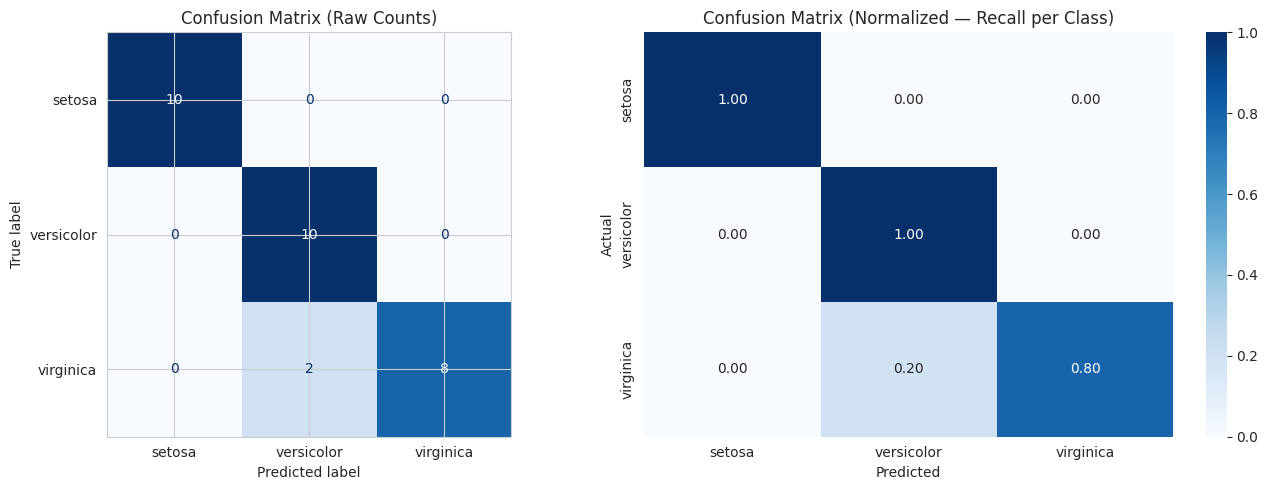

=== Reading the Confusion Matrix ===
  setosa      : 10/10 correct, 0 misclassified
  versicolor  : 10/10 correct, 0 misclassified
  virginica   : 8/10 correct, 2 misclassified


In [8]:
# ============================================================
# CELL 8: Confusion Matrix
# ============================================================
# A confusion matrix shows where the model gets confused.
#
# Layout (for 3 classes):
#           Predicted:
#            Set   Ver   Vir
# Actual: Set [ TN ][ FP ][ FP ]
#         Ver [ FN ][ TP ][ FP ]
#         Vir [ FN ][ FN ][ TP ]
#
# Diagonal = correct predictions
# Off-diagonal = mistakes (misclassifications)

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Raw counts ---
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Raw Counts)')

# --- Normalized (percentages) ---
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Divides each row by total actual samples in that class → shows recall per class
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix (Normalized — Recall per Class)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# --- Interpret ---
print("=== Reading the Confusion Matrix ===")
for i, cls in enumerate(iris.target_names):
    correct   = cm[i, i]
    total     = cm[i].sum()
    incorrect = total - correct
    print(f"  {cls:12s}: {correct}/{total} correct, {incorrect} misclassified")

Best K = 1 with Test Accuracy = 0.9667


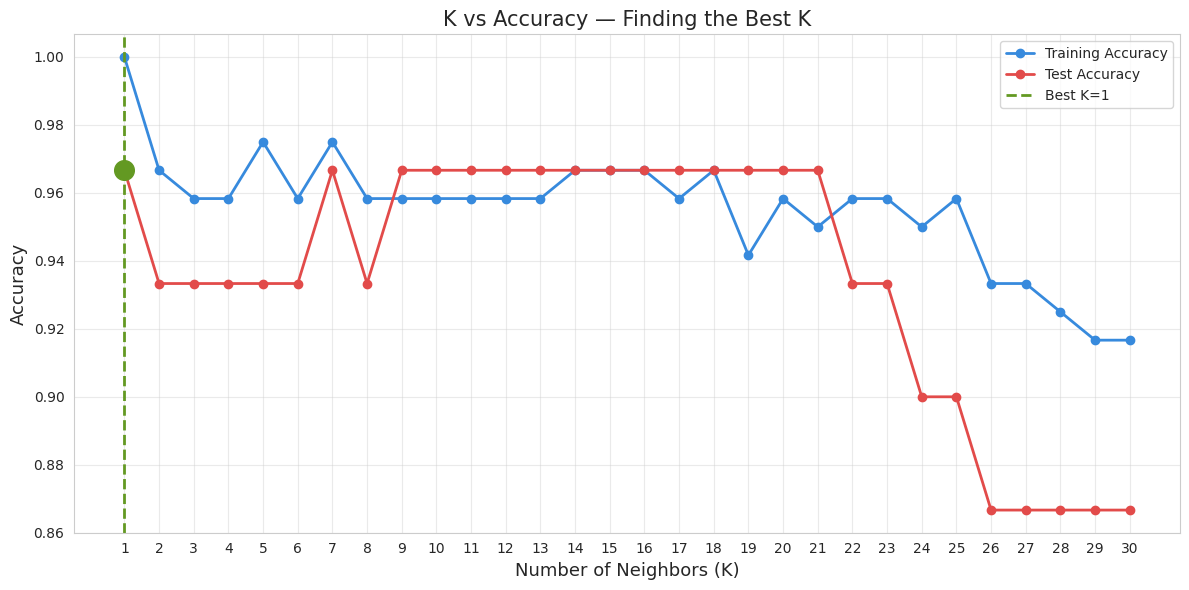

In [9]:
# ============================================================
# CELL 9: Finding the Optimal K (Elbow Method)
# ============================================================
# K is the most important hyperparameter in KNN.
# We try many values and pick the one with best test accuracy.
#
# WHY DOES K MATTER?
#   K=1: Only nearest neighbor votes → very flexible, can overfit
#   K=N: All points vote → always predicts majority class (underfit)
#   Best K: somewhere in between — we find it experimentally!

k_range = range(1, 31)  # Test K from 1 to 30
train_scores = []
test_scores  = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_k.fit(X_train_scaled, y_train)

    train_scores.append(knn_k.score(X_train_scaled, y_train))  # Train accuracy
    test_scores.append(knn_k.score(X_test_scaled, y_test))     # Test accuracy

# Find best K
best_k     = k_range[np.argmax(test_scores)]
best_score = max(test_scores)
print(f"Best K = {best_k} with Test Accuracy = {best_score:.4f}")

# --- Plot K vs Accuracy ---
plt.figure(figsize=(12, 6))
plt.plot(k_range, train_scores, 'o-', color='#378ADD', label='Training Accuracy', linewidth=2)
plt.plot(k_range, test_scores,  'o-', color='#E24B4A', label='Test Accuracy',     linewidth=2)
plt.axvline(x=best_k, color='#639922', linestyle='--', linewidth=2, label=f'Best K={best_k}')
plt.scatter([best_k], [best_score], color='#639922', s=200, zorder=5)
plt.xlabel('Number of Neighbors (K)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('K vs Accuracy — Finding the Best K', fontsize=15)
plt.legend()
plt.xticks(k_range)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Notice: train accuracy decreases as K increases (less flexible)
#         test accuracy first improves then may decrease (sweet spot!)

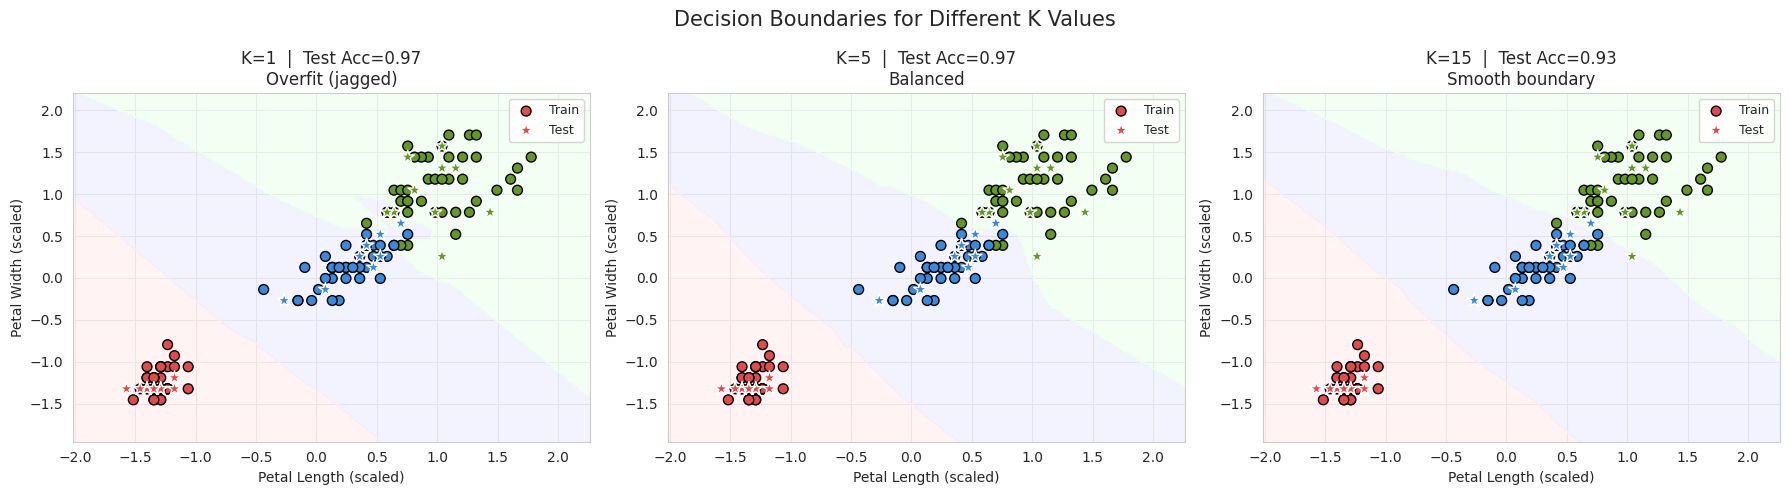

💡 K=1: jagged boundary (overfit). K=15: smooth (underfit risk). K=5: balanced.


In [10]:
# ============================================================
# CELL 10: Decision Boundary Visualization
# ============================================================
# A decision boundary shows which regions of feature space
# would be assigned to each class by the KNN model.
# We use only 2 features (petal dimensions) for 2D plotting.

# Use only petal features (best separation) for 2D visualization
X_2d       = iris.data[:, 2:4]  # petal length & petal width only
X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)
scaler_2d    = StandardScaler().fit(X_2d_train)
X_2d_sc_tr  = scaler_2d.transform(X_2d_train)
X_2d_sc_te  = scaler_2d.transform(X_2d_test)

# --- Plot decision boundaries for 3 different K values ---
k_values = [1, 5, 15]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cmap_bg  = ListedColormap(['#FFEEEE', '#EEEEFF', '#EEFFEE'])  # Soft background
cmap_pts = ListedColormap(['#E24B4A', '#378ADD', '#639922'])  # Vivid points

for ax, k in zip(axes, k_values):
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_2d_sc_tr, y_2d_train)

    # Create a dense mesh grid over the feature space
    h       = 0.02  # Grid step size (smaller = finer boundary)
    x_min, x_max = X_2d_sc_tr[:, 0].min() - 0.5, X_2d_sc_tr[:, 0].max() + 0.5
    y_min, y_max = X_2d_sc_tr[:, 1].min() - 0.5, X_2d_sc_tr[:, 1].max() + 0.5
    xx, yy  = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict class for every grid point (this draws the boundary)
    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.7)   # Fill regions
    ax.scatter(X_2d_sc_tr[:, 0], X_2d_sc_tr[:, 1], c=y_2d_train,
               cmap=cmap_pts, edgecolors='k', s=50, label='Train')
    ax.scatter(X_2d_sc_te[:, 0], X_2d_sc_te[:, 1], c=y_2d_test,
               cmap=cmap_pts, edgecolors='white', s=100, marker='*', label='Test')

    acc = knn_2d.score(X_2d_sc_te, y_2d_test)
    ax.set_title(f'K={k}  |  Test Acc={acc:.2f}\n{"Overfit (jagged)" if k==1 else "Smooth boundary" if k==15 else "Balanced"}', fontsize=12)
    ax.set_xlabel('Petal Length (scaled)')
    ax.set_ylabel('Petal Width (scaled)')
    ax.legend(fontsize=9)

plt.suptitle('Decision Boundaries for Different K Values', fontsize=15)
plt.tight_layout()
plt.show()
print("💡 K=1: jagged boundary (overfit). K=15: smooth (underfit risk). K=5: balanced.")

In [11]:
# ============================================================
# CELL 11: Cross-Validation & GridSearchCV
# ============================================================
# Cross-validation gives a more reliable accuracy estimate
# by testing on MULTIPLE splits of the data.
#
# 5-Fold CV:
#   Split data into 5 equal parts (folds).
#   Train on 4 folds → Test on 1 fold.
#   Repeat 5 times, each fold acts as test once.
#   Final score = average of all 5 test scores.

# --- Manual Cross-Validation ---
knn_cv = KNeighborsClassifier(n_neighbors=5)
cv_scores = cross_val_score(
    knn_cv,
    X_train_scaled, y_train,
    cv=5,              # 5-fold cross-validation
    scoring='accuracy'  # Metric to evaluate
)
print("=== 5-Fold Cross-Validation (K=5) ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
# Low std = model is consistent across different data splits

# --- GridSearchCV: Systematic Hyperparameter Tuning ---
# Tests ALL combinations of parameters and finds the best one.
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],  # K values to try
    'metric'     : ['euclidean', 'manhattan'],    # Distance metrics to try
    'weights'    : ['uniform', 'distance']        # Voting strategies to try
}
# 7 K values × 2 metrics × 2 weights = 28 combinations × 5 folds = 140 fits

grid_search = GridSearchCV(
    KNeighborsClassifier(),  # Base model
    param_grid,              # Parameter grid to search
    cv=5,                   # 5-fold CV for each combination
    scoring='accuracy',    # What to maximize
    n_jobs=-1               # Use all CPU cores for speed
)
grid_search.fit(X_train_scaled, y_train)

print(f"\n=== GridSearchCV Results ===")
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV Score   : {grid_search.best_score_:.4f}")
print(f"Test Accuracy   : {grid_search.score(X_test_scaled, y_test):.4f}")

# --- Use the best model ---
best_knn = grid_search.best_estimator_
print(f"\n✅ Best model: {best_knn}")

=== 5-Fold Cross-Validation (K=5) ===
  Fold 1: 0.9167
  Fold 2: 1.0000
  Fold 3: 0.9583
  Fold 4: 0.9583
  Fold 5: 1.0000
  Mean: 0.9667 ± 0.0312

=== GridSearchCV Results ===
Best Parameters : {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Best CV Score   : 0.9667
Test Accuracy   : 0.9333

✅ Best model: KNeighborsClassifier(metric='euclidean')


Dataset: 442 patients, 10 features
Target range: 25 to 346

=== Regression Metrics ===
MSE  (lower=better): 2942.48
RMSE (lower=better): 54.24  ← in same units as disease score
R²   (higher=better): 0.4446  ← 44.5% of variance explained


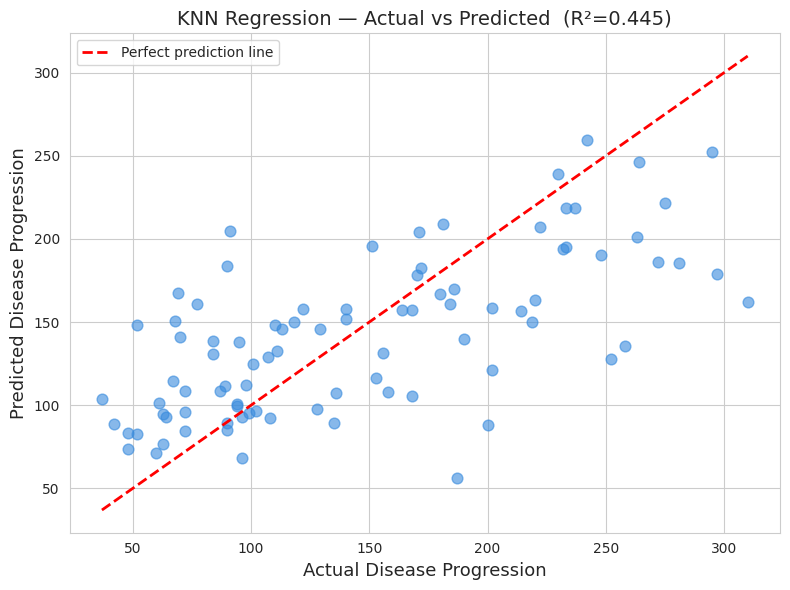

💡 Points near the red dashed line = accurate predictions!
🎉 You've completed the full KNN practice notebook!


In [12]:
# ============================================================
# CELL 12: KNN for Regression (Diabetes Dataset)
# ============================================================
# KNN isn't just for classification — it works for regression too!
# Instead of voting on a class, neighbors AVERAGE their target values.
#
# Diabetes dataset: Predict disease progression (a continuous number)
# from 10 medical features (age, BMI, blood pressure, etc.)

# --- Load regression dataset ---
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target  # Continuous values (disease progression score)

print(f"Dataset: {X_reg.shape[0]} patients, {X_reg.shape[1]} features")
print(f"Target range: {y_reg.min():.0f} to {y_reg.max():.0f}")

# Split and scale
X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
scaler_r      = StandardScaler().fit(X_r_train)
X_r_train_sc  = scaler_r.transform(X_r_train)
X_r_test_sc   = scaler_r.transform(X_r_test)

# --- Train KNN Regressor ---
knn_reg = KNeighborsRegressor(
    n_neighbors=7,      # Use 7 neighbors
    weights='distance',  # Closer neighbors have more influence
    metric='euclidean'
)
knn_reg.fit(X_r_train_sc, y_r_train)
y_r_pred = knn_reg.predict(X_r_test_sc)

# --- Evaluate Regression ---
mse  = mean_squared_error(y_r_test, y_r_pred)
rmse = np.sqrt(mse)                             # Root MSE (same units as target)
r2   = r2_score(y_r_test, y_r_pred)            # R² = 1 is perfect, 0 = baseline

print(f"\n=== Regression Metrics ===")
print(f"MSE  (lower=better): {mse:.2f}")
print(f"RMSE (lower=better): {rmse:.2f}  ← in same units as disease score")
print(f"R²   (higher=better): {r2:.4f}  ← {r2*100:.1f}% of variance explained")

# --- Actual vs Predicted scatter plot ---
plt.figure(figsize=(8, 6))
plt.scatter(y_r_test, y_r_pred, alpha=0.6, color='#378ADD', s=60)
plt.plot([y_r_test.min(), y_r_test.max()],
         [y_r_test.min(), y_r_test.max()],
         'r--', lw=2, label='Perfect prediction line')
plt.xlabel('Actual Disease Progression', fontsize=13)
plt.ylabel('Predicted Disease Progression', fontsize=13)
plt.title(f'KNN Regression — Actual vs Predicted  (R²={r2:.3f})', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()
print("💡 Points near the red dashed line = accurate predictions!")
print("🎉 You've completed the full KNN practice notebook!")